In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)
print((PROJECT_ROOT / "processing").exists())

c:\Users\johnm\fingerprint-feature-analyzer
True


In [5]:
from pathlib import Path
import os

print("Current notebook directory:")
print(Path.cwd())

print("\nFolders here:")
print(os.listdir())

Current notebook directory:
c:\Users\johnm\fingerprint-feature-analyzer\notebook

Folders here:
['01_dataset_eda.ipynb', '02_preprocessing_experiments.ipynb']


In [6]:
from processing.preprocessing import (
    load_image,
    convert_to_grayscale,
    normalize_image,
    denoise_image,
    enhance_contrast
)

print("Preprocessing module loaded successfully!")

Preprocessing module loaded successfully!


In [7]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

image_path = next(
    (PROJECT_ROOT / "data" / "raw" / "NISTDB4").rglob("*.png")
)

print("Image selected:")
print(image_path)

Image selected:
c:\Users\johnm\fingerprint-feature-analyzer\data\raw\NISTDB4\class1_Arc\class1_Arc_0001.png


In [8]:
image = load_image(image_path)

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)

Image shape: (512, 512)
Image dtype: uint8


In [9]:
gray_image = convert_to_grayscale(image)

normalized_image = normalize_image(gray_image)

denoised_image = denoise_image(normalized_image)

enhanced_image = enhance_contrast(denoised_image)

print("Preprocessing completed.")

Preprocessing completed.


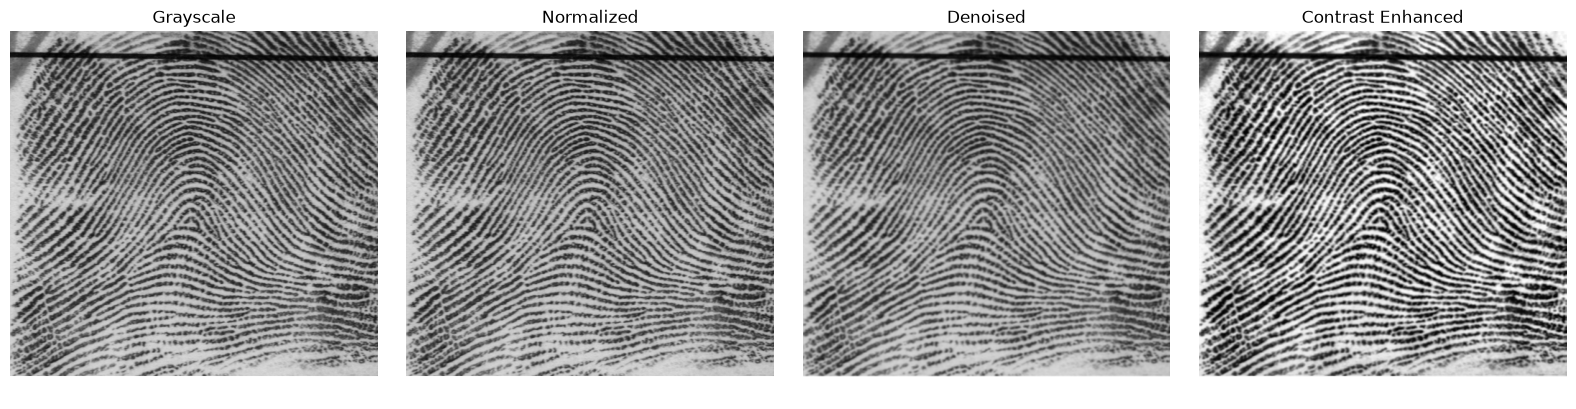

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(gray_image, cmap="gray")
axes[0].set_title("Grayscale")

axes[1].imshow(normalized_image, cmap="gray")
axes[1].set_title("Normalized")

axes[2].imshow(denoised_image, cmap="gray")
axes[2].set_title("Denoised")

axes[3].imshow(enhanced_image, cmap="gray")
axes[3].set_title("Contrast Enhanced")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
from processing.segmentation import segment_fingerprint

print("Segmentation module loaded!")

Segmentation module loaded!


In [12]:
mask = segment_fingerprint(enhanced_image)

print("Mask shape:", mask.shape)
print("Mask dtype:", mask.dtype)

Mask shape: (512, 512)
Mask dtype: uint8


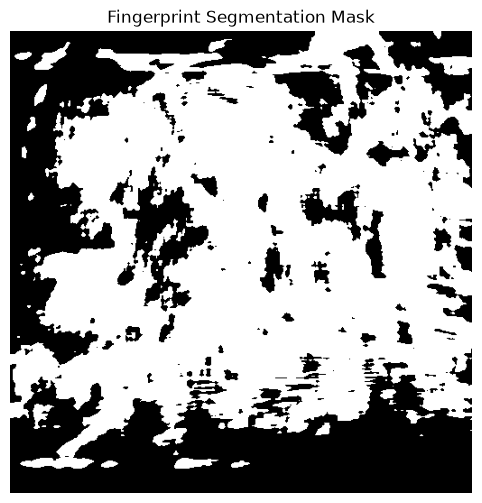

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="gray")
plt.title("Fingerprint Segmentation Mask")
plt.axis("off")
plt.show()

In [15]:
print(enhanced_image.min())
print(enhanced_image.max())
print(enhanced_image.mean())

0
255
144.37030029296875
